# Сравнительный OCR-бенчмарк: pix2tex vs Texify vs Uni-MuMER

Датасет: CROHME 2014 test (986 изображений рукописной математики)

Метрика: CER (Character Error Rate) с нормализацией LaTeX

**Архитектура ноутбука:**
1. Загрузка датасета
2. Прогон pix2tex → сохранение `pix2tex_raw.json`
3. Прогон Texify → сохранение `texify_raw.json`
4. Прогон Uni-MuMER → сохранение `unimumer_raw.json`
5. Нормализация LaTeX (применяется один раз ко всем результатам)
6. Подсчёт CER и сравнение моделей


## 0. Загрузка датасета

In [13]:
import os

ROOT    = '/kaggle/input/datasets/jungomi/chrome-png/data'
IMG_DIR = f'{ROOT}/test/2014'
GT_FILE = f'{ROOT}/groundtruth_2014.tsv'

ground_truth = {}
with open(GT_FILE, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split('\t', 1)
        if len(parts) != 2:
            continue
        fname, latex = parts
        fname = fname.strip()
        latex = latex.strip()
        for ext in ['.png', '.bmp', '.jpg', '']:
            img_path = os.path.join(IMG_DIR, fname + ext)
            if os.path.exists(img_path):
                ground_truth[img_path] = latex
                break

print(f'Загружено пар изображение-LaTeX: {len(ground_truth)}')
sample_key = list(ground_truth.keys())[0]
print(f'Пример: {sample_key} -> {ground_truth[sample_key]}')

Загружено пар изображение-LaTeX: 986
Пример: /kaggle/input/datasets/jungomi/chrome-png/data/test/2014/18_em_22.png -> p_1^{\gamma_1}p_2^{\gamma_2}\cdots p_n^{\gamma_n}


---
## 1. pix2tex (13M)
Если уже есть сохранённый `pix2tex_raw.json` в `/kaggle/working/`, эту секцию можно пропустить.

In [ ]:
!pip install pix2tex -q

In [ ]:
import json, time, os
from tqdm import tqdm
from PIL import Image

OUT_FILE = '/kaggle/working/pix2tex_raw.json'

if os.path.exists(OUT_FILE):
    print(f'{OUT_FILE} уже существует, пропускаем прогон.')
else:
    from pix2tex.cli import LatexOCR
    print('Загружаем pix2tex...')
    model_p2t = LatexOCR()
    print('Загружено!')

    raw_results = []
    items = list(ground_truth.items())
    start = time.time()
    for img_path, gt in tqdm(items):
        try:
            img = Image.open(img_path).convert('RGB')
            pred = model_p2t(img)
        except Exception as e:
            pred = ''
        raw_results.append({'image': img_path, 'gt': gt, 'pred': pred})
    elapsed = time.time() - start
    print(f'Готово за {elapsed/60:.1f} мин')

    with open(OUT_FILE, 'w', encoding='utf-8') as f:
        json.dump({'model': 'pix2tex', 'raw_results': raw_results}, f, ensure_ascii=False, indent=2)
    print(f'Сохранено: {OUT_FILE}')

---
## 2. Texify (625M)

In [2]:
!pip install -q transformers==4.40.0
!pip install texify -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 108.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 99.4 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [3]:
import json, time, os
from tqdm import tqdm
from PIL import Image

OUT_FILE = '/kaggle/working/texify_raw.json'

if os.path.exists(OUT_FILE):
    print(f'{OUT_FILE} уже существует, пропускаем прогон.')
else:
    from transformers import AutoImageProcessor
    from texify.model.model import load_model
    from texify.model.processor import VariableDonutSwinConfig, VariableDonutImageProcessor, VariableDonutProcessor
    from texify.settings import settings
    from texify.inference import batch_inference

    print('Загружаем Texify...')
    model_tex = load_model()
    AutoImageProcessor.register(VariableDonutSwinConfig, VariableDonutImageProcessor)
    processor_tex = VariableDonutProcessor.from_pretrained(settings.MODEL_CHECKPOINT)
    processor_tex.image_processor.max_size = settings.MAX_IMAGE_SIZE
    print('Загружено!')

    raw_results = []
    items = list(ground_truth.items())
    BATCH = 8
    start = time.time()
    n_batch_errors = 0
    for i in tqdm(range(0, len(items), BATCH)):
        batch_items = items[i:i+BATCH]
        batch_imgs = []
        for img_path, _ in batch_items:
            try:
                batch_imgs.append(Image.open(img_path).convert('RGB'))
            except Exception:
                batch_imgs.append(None)
        valid_imgs = [im for im in batch_imgs if im is not None]
        try:
            preds = batch_inference(valid_imgs, model_tex, processor_tex) if valid_imgs else []
        except Exception as e:
            n_batch_errors += 1
            if n_batch_errors <= 3:
                print(f'BATCH ERROR at i={i}: {type(e).__name__}: {e}')
            preds = [''] * len(valid_imgs)
        pred_idx = 0
        for (img_path, gt), img in zip(batch_items, batch_imgs):
            if img is None:
                raw_results.append({'image': img_path, 'gt': gt, 'pred': ''})
                continue
            pred = preds[pred_idx] if pred_idx < len(preds) else ''
            pred_idx += 1
            raw_results.append({'image': img_path, 'gt': gt, 'pred': pred})
    elapsed = time.time() - start
    print(f'Готово за {elapsed/60:.1f} мин')
    print(f'Всего ошибок батчей: {n_batch_errors}')

    with open(OUT_FILE, 'w', encoding='utf-8') as f:
        json.dump({'model': 'Texify', 'raw_results': raw_results}, f, ensure_ascii=False, indent=2)
    print(f'Сохранено: {OUT_FILE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 84.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 110.3 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
dopamine-rl 4.1.

2026-06-21 10:07:26.393471: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782036446.618943      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782036446.685130      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782036447.231582      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782036447.231631      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782036447.231634      58 computation_placer.cc:177] computation placer alr

Загружаем Texify...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

Загружено!


100%|██████████| 124/124 [02:16<00:00,  1.10s/it]

Готово за 2.3 мин
Всего ошибок батчей: 0
Сохранено: /kaggle/working/texify_raw.json


---
## 3. Uni-MuMER-Qwen3-VL-4B


In [ ]:
import json, time, os
from tqdm import tqdm
from PIL import Image
import torch

OUT_FILE = '/kaggle/working/unimumer_raw.json'

if os.path.exists(OUT_FILE):
    print(f'{OUT_FILE} уже существует, пропускаем прогон.')
else:
    from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Устройство: {device}')
    cap = torch.cuda.get_device_capability(0) if device == 'cuda' else (0, 0)
    print(f'CUDA capability: {cap}')
    if cap[0] < 7:
        print('!!! ВНИМАНИЕ: GPU слишком старая (нужна >= 7.0). Переключи на T4 x2 в Settings -> Accelerator и перезапусти.')

    model_id = 'phxember/Uni-MuMER-Qwen3-VL-4B'
    print('Загружаем процессор...')
    processor_um = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
    print('Загружаем модель (4.4B, может занять пару минут)...')
    model_um = Qwen3VLForConditionalGeneration.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        device_map='auto',
        trust_remote_code=True,
    )
    model_um.eval()
    print('Загружено!')

    def predict_unimumer(img_path):
        img = Image.open(img_path).convert('RGB')
        messages = [{
            'role': 'user',
            'content': [
                {'type': 'image', 'image': img},
                {'type': 'text', 'text': 'Recognize the handwritten mathematical expression and output LaTeX only.'},
            ]
        }]
        text = processor_um.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor_um(text=[text], images=[img], return_tensors='pt').to(device)
        with torch.no_grad():
            output = model_um.generate(**inputs, max_new_tokens=256, do_sample=False)
        return processor_um.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    raw_results = []
    items = list(ground_truth.items())
    start = time.time()
    for img_path, gt in tqdm(items):
        try:
            pred = predict_unimumer(img_path)
        except Exception as e:
            pred = ''
        raw_results.append({'image': img_path, 'gt': gt, 'pred': pred})
        # Промежуточное сохранение каждые 100 изображений на случай обрыва сессии
        if len(raw_results) % 100 == 0:
            with open(OUT_FILE + '.partial', 'w', encoding='utf-8') as f:
                json.dump({'model': 'Uni-MuMER-Qwen3-VL-4B', 'raw_results': raw_results}, f, ensure_ascii=False, indent=2)
    elapsed = time.time() - start
    print(f'Готово за {elapsed/60:.1f} мин')

    with open(OUT_FILE, 'w', encoding='utf-8') as f:
        json.dump({'model': 'Uni-MuMER-Qwen3-VL-4B', 'raw_results': raw_results}, f, ensure_ascii=False, indent=2)
    print(f'Сохранено: {OUT_FILE}')
    if os.path.exists(OUT_FILE + '.partial'):
        os.remove(OUT_FILE + '.partial')

---
## 4. Загрузка всех сырых результатов


In [14]:
import json

all_raw = {}
for name, fname in [('pix2tex', 'pix2tex_raw.json'),
                     ('Texify', 'texify_raw.json'),
                     ('Uni-MuMER', 'unimumer_raw.json')]:
    path = f'/kaggle/input/datasets/drayvol/models-results/{fname}'
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    all_raw[name] = data['raw_results']
    print(f'{name:<12}: {len(data["raw_results"])} результатов загружено из {fname}')

pix2tex     : 986 результатов загружено из pix2tex_raw.json
Texify      : 986 результатов загружено из texify_raw.json
Uni-MuMER   : 986 результатов загружено из unimumer_raw.json


---
## 5. Нормализация LaTeX
Применяется одинаково ко всем трём моделям, чтобы сравнение было честным.

Что нормализуем:
- обёртки `$$...$$`, `\mathrm{}`, `\begin{matrix}...\end{matrix}`
- пробелы вокруг `_ ^ { }`, между цифрами, внутри скобок
- `\left( \right)` -> `( )`
- разорванные команды (`lo g` -> `\log`)
- эквивалентные обозначения (`\circ` -> `o`, греческие буквы похожие на латинские при рукописном вводе)
- порядок `_{}^{}` -> `^{}_{}`
- обрезаем зацикленный бред модели (`\bar{\bar{\bar{...`)

In [2]:
pip install Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.6 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [16]:
import re
import Levenshtein

LATEX_CMDS = ['infty', 'cdots', 'ldots', 'rightarrow', 'leftarrow',
              'neq', 'leq', 'geq', 'cdot', 'times', 'pm', 'mp',
              'alpha', 'beta', 'gamma', 'delta', 'theta', 'lambda',
              'sigma', 'phi', 'psi', 'omega', 'mu', 'nu',
              'frac', 'sqrt', 'sum', 'int', 'lim',
              'log', 'sin', 'cos', 'tan', 'pi',
              'subset', 'approx', 'equiv', 'notin']

def restore_commands(s):
    """Восстанавливает разорванные LaTeX команды без обратного слэша (lo g -> \\log)."""
    for cmd in sorted(LATEX_CMDS, key=len, reverse=True):
        replacement = '\\\\' + cmd
        s = re.sub(r'(?<!\\)(?<![a-zA-Z])' + cmd + r'(?![a-zA-Z])', replacement, s)
    return s

def normalize_latex(s):
    if s is None:
        s = ''
    s = re.sub(r'(\\bar\{){3,}.*', '', s)
    s = re.sub(r'(\\begin\{matrix\}){2,}.*', '', s)

    s = re.sub(r'^\$\$|\$\$$', '', s).strip()
    s = re.sub(r'\\math\w+\{([^{}]*)\}', r'\1', s)
    s = re.sub(r'\\text\{([^{}]*)\}', r'\1', s)
    s = re.sub(r'\\begin\{[^}]+\}(.*?)\\end\{[^}]+\}', r'\1', s, flags=re.DOTALL)
    for _ in range(10):
        s = re.sub(r'\\(?:bar|hat|tilde|vec|dot|ddot)\{([^{}]*)\}', r'\1', s)
    s = re.sub(r'\\[!,;]', '', s)
    s = re.sub(r'\\quad|\\qquad', ' ', s)
    s = re.sub(r'\\left\s*\(', '(', s)
    s = re.sub(r'\\right\s*\)', ')', s)
    s = re.sub(r'\\left\s*\[', '[', s)
    s = re.sub(r'\\right\s*\]', ']', s)
    s = re.sub(r'\\limits', '', s)
    s = re.sub(r'\\(l|c)dots', r'\\cdots', s)
    s = re.sub(r'\\cdot\s*\\cdot\s*\\cdot', r'\\cdots', s)
    s = re.sub(r'\\circ', 'o', s)
    s = re.sub(r'\\omega', 'w', s)
    s = re.sub(r'\\kappa', 'k', s)
    s = re.sub(r'\\rho', 'p', s)
    s = re.sub(r'\\lt\b', '<', s)
    s = re.sub(r'\\gt\b', '>', s)
    s = re.sub(r'\\(\d)', r'\1', s)

    # СНАЧАЛА убираем пробелы вокруг _ ^ { }
    s = re.sub(r'\s*([_^{}])\s*', r'\1', s)
    # ПОТОМ переставляем порядок sub/sup (теперь без пробелов, паттерн матчится всегда одинаково)
    s = re.sub(r'(_\{[^{}]*\})(\^\{[^{}]*\})', r'\2\1', s)
    s = re.sub(r'(_[^{^\s])(\^[^{^\s])', r'\2\1', s)

    for _ in range(5):
        s = re.sub(r'\{([^{}])\}', r'\1', s)

    s = re.sub(r'(\d)\s+\.\s+(\d)', r'\1.\2', s)
    s = re.sub(r'(\d)\s+(\d)', r'\1\2', s)
    s = re.sub(r'(?<!\\)(?<![a-zA-Z])([a-zA-Z0-9])\s+([a-zA-Z0-9])(?![a-zA-Z])', r'\1\2', s)
    s = re.sub(r'\(\s+', '(', s)
    s = re.sub(r'\s+\)', ')', s)
    s = re.sub(r'\[\s+', '[', s)
    s = re.sub(r'\s+\]', ']', s)
    s = re.sub(r'\s*,\s*', ',', s)
    s = re.sub(r'\s*(\\neq|\\leq|\\geq|\\approx|\\equiv|\\sim|\\notin|\\subset)\s*', r' \1 ', s)
    s = re.sub(r'\s*([=+\-<>])\s*', r' \1 ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    s = s.lower()
    return s

def full_normalize(s):
    s = restore_commands(s)
    s = normalize_latex(s)
    return s

def compute_cer(reference, hypothesis):
    if len(reference) == 0:
        return 0.0 if len(hypothesis) == 0 else 1.0
    return min(1.0, Levenshtein.distance(reference, hypothesis) / len(reference))

# Самопроверка нормализации
tests = [
    (r'x_{1}^{2}',  r'x _ { 1 } ^ { 2 }'),
    (r'\frac{a}{b}', r'\frac { a } { b }'),
    (r'\sum^{\infty}_{n=1}', r'sum^{infty}_{n = 1}'),
    (r'n \neq 0', r'n neq 0'),
    (r'\mathrm{Im}', r'Im'),
]
print('Самопроверка нормализации:')
for gt, pred in tests:
    g, p = full_normalize(gt), full_normalize(pred)
    cer = compute_cer(g, p)
    status = 'OK' if cer == 0.0 else f'CER={cer*100:.1f}%'
    print(f'  [{status}] {gt!r} vs {pred!r}')

Самопроверка нормализации:
  [OK] 'x_{1}^{2}' vs 'x _ { 1 } ^ { 2 }'
  [OK] '\\frac{a}{b}' vs '\\frac { a } { b }'
  [OK] '\\sum^{\\infty}_{n=1}' vs 'sum^{infty}_{n = 1}'
  [OK] 'n \\neq 0' vs 'n neq 0'
  [OK] '\\mathrm{Im}' vs 'Im'


In [35]:
def is_corrupted_image(img_path):
    """
    Определяет структурно повреждённые изображения датасета:
    - почти пустые (меньше 1% тёмных пикселей)
    - содержащие артефакты рендеринга в виде рамок (длинные ровные линии)
    """
    img = Image.open(img_path).convert('L')
    arr = np.array(img)
    dark = arr < 128
    dark_ratio = dark.sum() / arr.size

    if dark_ratio < 0.01:
        return True, 'blank'

    row_sums = dark.sum(axis=1) / arr.shape[1]
    col_sums = dark.sum(axis=0) / arr.shape[0]
    long_h = (row_sums > 0.9).sum()
    long_v = (col_sums > 0.9).sum()
    if long_h >= 2 or long_v >= 2:
        return True, 'frame_artifact'

    return False, None

corrupted = {}
for img_path in ground_truth:
    is_bad, reason = is_corrupted_image(img_path)
    if is_bad:
        corrupted[img_path] = reason

corrupted_set = set(corrupted.keys())
from collections import Counter
print(f'Исключаем {len(corrupted_set)} структурно повреждённых изображений из {len(ground_truth)}')
print(Counter(corrupted.values()))


Исключаем 34 структурно повреждённых изображений из 986
Counter({'blank': 25, 'frame_artifact': 9})


---
## 6. Подсчёт CER для всех моделей

In [36]:
import numpy as np

def evaluate_model(raw_results, exclude_images=None):
    """Считает CER для каждого предсказания, исключая повреждённые изображения."""
    exclude_images = exclude_images or set()
    scored = []
    for r in raw_results:
        if r['image'] in exclude_images:
            continue
        gt_n   = full_normalize(r['gt'])
        pred_n = full_normalize(r['pred'])
        cer = compute_cer(gt_n, pred_n)
        scored.append({**r, 'gt_norm': gt_n, 'pred_norm': pred_n, 'cer': cer})
    cer_values = [s['cer'] for s in scored]
    stats = {
        'n':         len(cer_values),
        'mean':      float(np.mean(cer_values)),
        'median':    float(np.median(cer_values)),
        'perfect':   sum(1 for c in cer_values if c == 0.0),
        'below_10':  sum(1 for c in cer_values if c < 0.10),
        'below_20':  sum(1 for c in cer_values if c < 0.20),
    }
    return scored, stats

all_scored = {}
all_stats  = {}
for name, raw in all_raw.items():
    scored, stats = evaluate_model(raw, exclude_images=corrupted_set)
    all_scored[name] = scored
    all_stats[name]  = stats

print('=' * 75)
print(f'  Сравнение OCR моделей на CROHME 2014, очищенный датасет ({len(ground_truth) - len(corrupted_set)} из {len(ground_truth)} изображений)')
print('=' * 75)
print(f'  {"Модель":<14} {"Ср.CER":>8} {"Медиана":>8} {"CER=0%":>9} {"CER<10%":>9} {"CER<20%":>9}')
print('-' * 75)
for name, s in all_stats.items():
    print(f'  {name:<14} {s["mean"]*100:>7.2f}% {s["median"]*100:>7.2f}% '
          f'{s["perfect"]:>4}({s["perfect"]/s["n"]*100:>4.1f}%) '
          f'{s["below_10"]:>4}({s["below_10"]/s["n"]*100:>4.1f}%) '
          f'{s["below_20"]:>4}({s["below_20"]/s["n"]*100:>4.1f}%)')
print('=' * 75)


  Сравнение OCR моделей на CROHME 2014, очищенный датасет (952 из 986 изображений)
  Модель           Ср.CER  Медиана    CER=0%   CER<10%   CER<20%
---------------------------------------------------------------------------
  pix2tex          97.71%  100.00%    0( 0.0%)    0( 0.0%)    1( 0.1%)
  Texify           32.25%   16.67%  273(28.7%)  384(40.3%)  508(53.4%)
  Uni-MuMER        10.44%    0.00%  522(54.8%)  682(71.6%)  786(82.6%)


---
## 7. Сохранение итоговых результатов

In [37]:
import json

final_report = {
    'dataset': 'CROHME 2014 test',
    'n_images': len(ground_truth),
    'metric': 'CER (Character Error Rate) после нормализации LaTeX',
    'models': {},
}
for name in all_raw:
    final_report['models'][name] = {
        'stats': all_stats[name],
        'results': all_scored[name],
    }

with open('/kaggle/working/ocr_benchmark_final.json', 'w', encoding='utf-8') as f:
    json.dump(final_report, f, ensure_ascii=False, indent=2)

print('Сохранено: /kaggle/working/ocr_benchmark_final.json')
print(f'Размер файла: {os.path.getsize("/kaggle/working/ocr_benchmark_final.json") / 1024 / 1024:.1f} MB')

Сохранено: /kaggle/working/ocr_benchmark_final.json
Размер файла: 1.1 MB


---
## 8. Визуализация сравнения

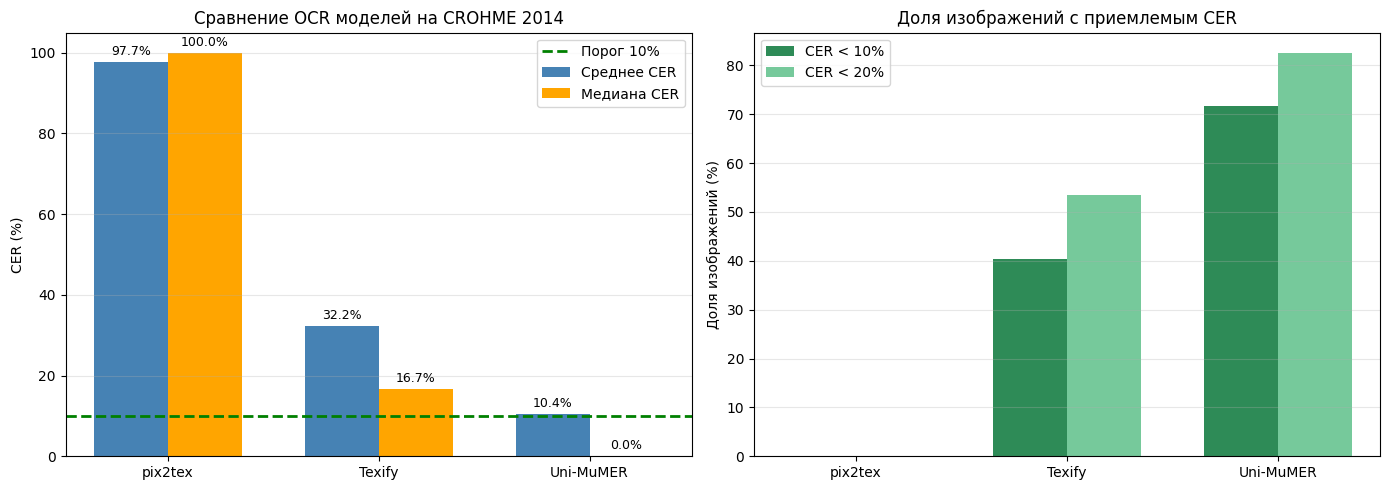

График сохранён: /kaggle/working/ocr_models_comparison.png


In [38]:
import matplotlib.pyplot as plt

names  = list(all_stats.keys())
means  = [all_stats[n]['mean']*100 for n in names]
medians= [all_stats[n]['median']*100 for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(names))
width = 0.35
bars1 = ax.bar(x - width/2, means,   width, label='Среднее CER', color='steelblue')
bars2 = ax.bar(x + width/2, medians, width, label='Медиана CER', color='orange')
ax.axhline(10, color='green', linestyle='--', linewidth=2, label='Порог 10%')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('CER (%)')
ax.set_title('Сравнение OCR моделей на CROHME 2014')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax = axes[1]
below10 = [all_stats[n]['below_10']/all_stats[n]['n']*100 for n in names]
below20 = [all_stats[n]['below_20']/all_stats[n]['n']*100 for n in names]
ax.bar(x - width/2, below10, width, label='CER < 10%', color='seagreen')
ax.bar(x + width/2, below20, width, label='CER < 20%', color='mediumseagreen', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Доля изображений (%)')
ax.set_title('Доля изображений с приемлемым CER')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/ocr_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: /kaggle/working/ocr_models_comparison.png')

---
## 9. Лучшие/худшие примеры для каждой модели

In [39]:
for name, scored in all_scored.items():
    sorted_s = sorted(scored, key=lambda x: x['cer'])
    print(f'\n{"="*60}')
    print(f'  {name} — 3 лучших / 3 худших примера')
    print(f'{"="*60}')
    for r in sorted_s[:3]:
        print(f"  [ЛУЧШИЙ]  CER={r['cer']*100:.1f}% | GT: {r['gt_norm'][:40]} | Pred: {r['pred_norm'][:40]}")
    for r in sorted_s[-3:]:
        print(f"  [ХУДШИЙ]  CER={r['cer']*100:.1f}% | GT: {r['gt_norm'][:40]} | Pred: {r['pred_norm'][:40]}")


  pix2tex — 3 лучших / 3 худших примера
  [ЛУЧШИЙ]  CER=13.6% | GT: x(t) = x_1(t) + x_2(t) | Pred: x(t) = x_u(t) + x_u(c)
  [ЛУЧШИЙ]  CER=27.0% | GT: 3( - 5)^2 + 3( - 5 - 2) - ( - 5)(2)^2 | Pred: 3( - 5)^4 + 3( - 5 - 2) - 1 - 5)(2)^{\fr
  [ЛУЧШИЙ]  CER=34.7% | GT: \beta_0(1) + \beta_1(i) + \beta_2(j) + \ | Pred: \beta_0(j) + \beta_i(\varphi)_ + \beta_2
  [ХУДШИЙ]  CER=100.0% | GT: 299\ 792\ 458 | Pred: l^{\alpha}\b \mp\mp12 \phi\ s\otimes
  [ХУДШИЙ]  CER=100.0% | GT: | ab | = | a | \cdot | b | | Pred: \left|u\right|\bigcup_u\left|d\right|d\r
  [ХУДШИЙ]  CER=100.0% | GT: | z - z_1| = | z - z_2| | Pred: \left|l\overlinezz\right|\right| - \left

  Texify — 3 лучших / 3 худших примера
  [ЛУЧШИЙ]  CER=0.0% | GT: \sqrt{ab} = \sqrta\sqrtb | Pred: \sqrt{ab} = \sqrta\sqrtb
  [ЛУЧШИЙ]  CER=0.0% | GT: 0.0878 | Pred: 0.0878
  [ЛУЧШИЙ]  CER=0.0% | GT: - a + b + c | Pred: - a + b + c
  [ХУДШИЙ]  CER=100.0% | GT: kg | Pred: k_0
  [ХУДШИЙ]  CER=100.0% | GT: bf fs | Pred: {~b~ + {~f~~s~}}
  [ХУДШИЙ]  

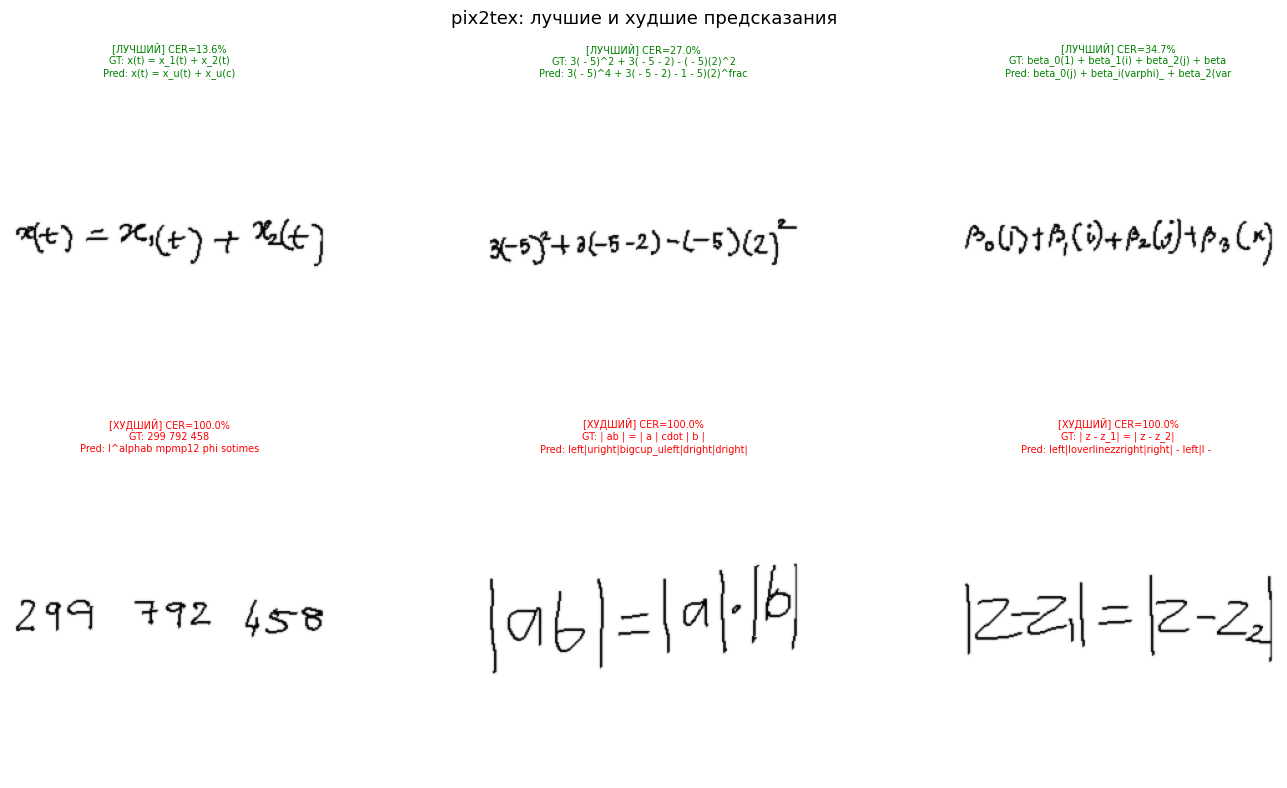

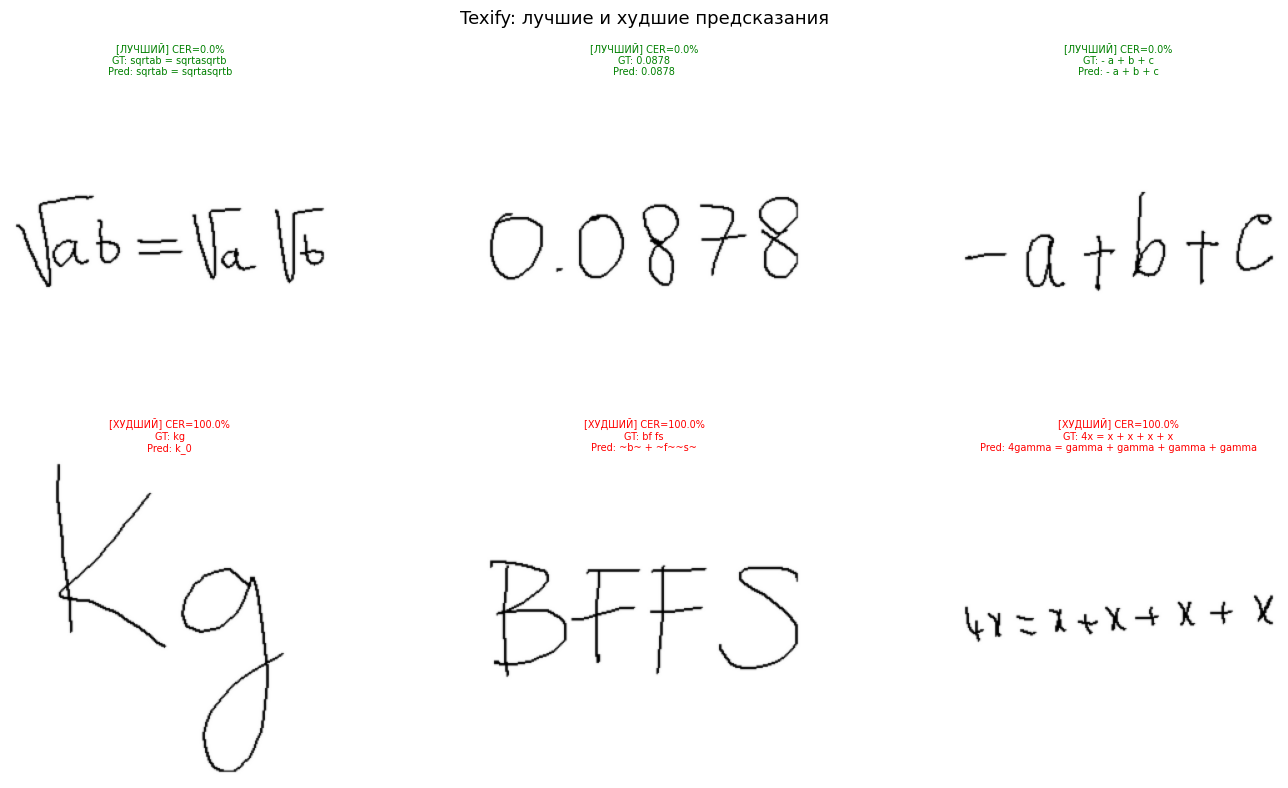

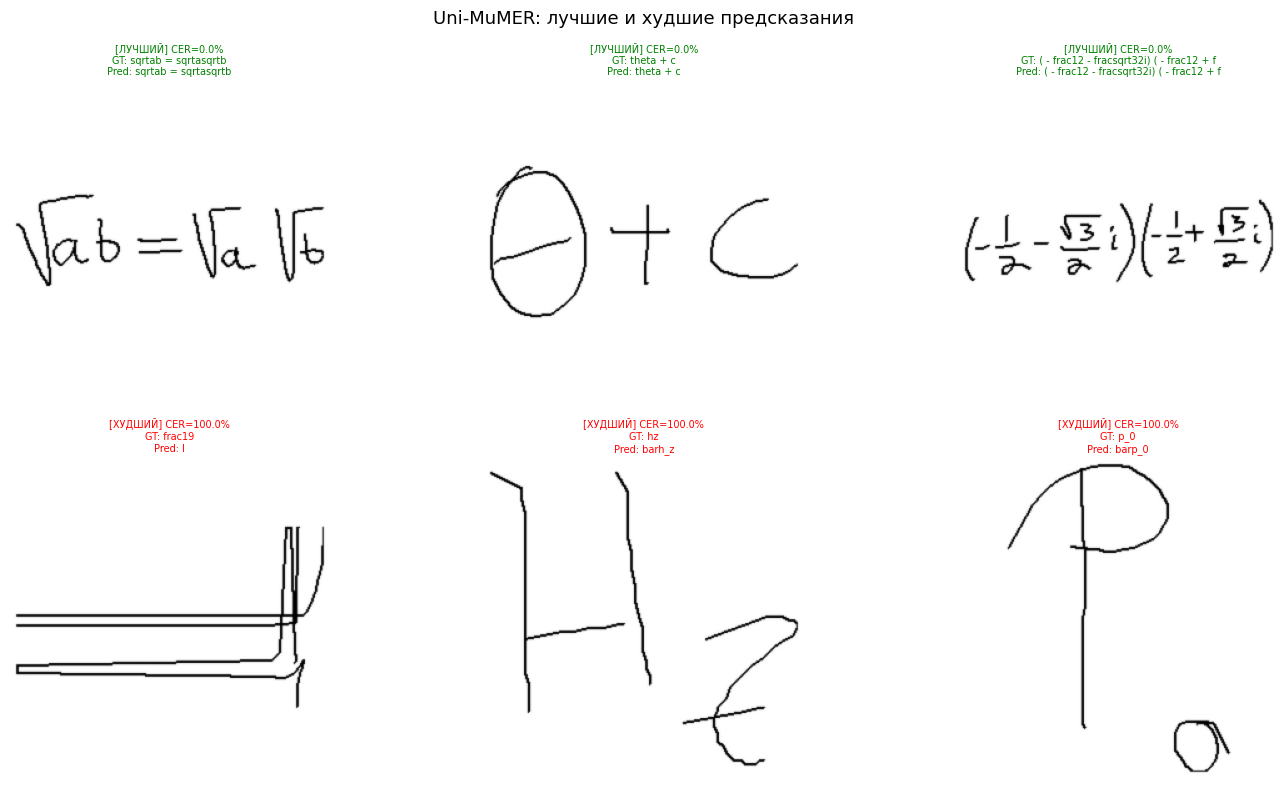

In [40]:
import matplotlib.pyplot as plt
from PIL import Image
import re

def safe_text(s, max_len=40):
    s = re.sub(r'[\\{}$]', '', s)
    return s[:max_len]

for name, scored in all_scored.items():
    sorted_s = sorted(scored, key=lambda x: x['cer'])
    best  = sorted_s[:3]
    worst = sorted_s[-3:]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for i, (r, ax) in enumerate(zip(best + worst, axes.flatten())):
        img = Image.open(r['image'])
        ax.imshow(img, cmap='gray')
        color = 'green' if i < 3 else 'red'
        label = 'ЛУЧШИЙ' if i < 3 else 'ХУДШИЙ'
        title = f"[{label}] CER={r['cer']*100:.1f}%\nGT: {safe_text(r['gt_norm'])}\nPred: {safe_text(r['pred_norm'])}"
        ax.set_title(title, fontsize=7, color=color)
        ax.axis('off')

    plt.suptitle(f'{name}: лучшие и худшие предсказания', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{name.replace(" ", "_")}_best_worst.png', dpi=150, bbox_inches='tight')
    plt.show()